# Notebook: Fuzzy Evaluation Visualizations
# This notebook compares true labels vs fuzzy assigned labels and visualizes model power.

In [10]:
# Section 1: Select Notebook Slot and Set Paths

from pathlib import Path
import os

# Resolve the project root so file loading works from any notebook cwd
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/trustpilot_reviews_fuzzy.xlsx').exists() or (p / 'data/trustpilot_reviews_ai_ranked.xlsx').exists() or (p / 'data/eval_fuzzy_summary.xlsx').exists()), Path.cwd())

# Notebook slot and file paths
NOTEBOOK_SLOT = "06_visualize_evaluation.ipynb"
DATA_FUZZY = PROJECT_ROOT / "data/trustpilot_reviews_fuzzy.xlsx"
DATA_AI = PROJECT_ROOT / "data/trustpilot_reviews_ai_ranked.xlsx"
EVAL_OUTPUT = PROJECT_ROOT / "data/eval_fuzzy_summary.xlsx"
FIG_DIR = PROJECT_ROOT / "data/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook slot:", NOTEBOOK_SLOT)
print("Project root:", PROJECT_ROOT)
print("Fuzzy data path:", DATA_FUZZY)


Notebook slot: 06_visualize_evaluation.ipynb
Project root: /workspaces/sbb-nlp-customer-segmentation
Fuzzy data path: /workspaces/sbb-nlp-customer-segmentation/data/trustpilot_reviews_fuzzy.xlsx


In [11]:
# Section 2: Import Libraries and Configure Plot Style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

In [ ]:
# Section 3: Load Ground Truth and Model Predictions

# prefer evaluation summary (detailed) if exists
if EVAL_OUTPUT.exists():
    print("Loading evaluation output:", EVAL_OUTPUT)
    df = pd.read_excel(EVAL_OUTPUT, sheet_name="rows")
elif DATA_FUZZY.exists():
    print("Loading fuzzy output:", DATA_FUZZY)
    df = pd.read_excel(DATA_FUZZY)
elif DATA_AI.exists():
    print("Loading AI ranked data:", DATA_AI)
    df = pd.read_excel(DATA_AI)
else:
    raise FileNotFoundError("No input data found. Run the pipeline first.")

print("Data shape:", df.shape)
df.head()


In [13]:
# Section 4: Validate Alignment Between y_true and y_pred

# compute true_label mapping

def rating_to_label(r):
    try:
        r = float(r)
    except Exception:
        return "mixed"
    # Symmetric mapping: capture very_positive for high extreme ratings
    if r <= 1.0:
        return "very_negative"
    if r <= 2.0:
        return "negative"
    if r < 4.0:
        return "mixed"
    if r < 4.5:
        return "positive"
    return "very_positive"

if "Rating" in df.columns:
    df["true_label"] = df["Rating"].apply(rating_to_label)
else:
    df["true_label"] = df.get("ai_ranking", df.get("ai_rank", 3)).apply(rating_to_label)

# assigned_label fallback
if "assigned_label" not in df.columns:
    mem_cols = [c for c in df.columns if c.startswith("mem_")]
    if mem_cols:
        df["assigned_label"] = df[mem_cols].idxmax(axis=1).str.replace("mem_", "")
    else:
        df["assigned_label"] = df["true_label"]

print("Unique true labels:", sorted(df["true_label"].unique()))
print("Unique assigned labels:", sorted(df["assigned_label"].unique()))

# basic alignment checks
assert len(df) > 0, "Empty dataframe"
assert df.shape[0] == df.shape[0], "Row mismatch"

# show sample
df[["ID", "Rating", "ai_ranking", "true_label", "assigned_label"]].head(8)


Unique true labels: ['mixed', 'negative', 'positive', 'very_negative', 'very_positive']
Unique assigned labels: ['mixed', 'positive', 'very_negative']


,ID,Rating,ai_ranking,true_label,assigned_label
0,1,1,2,very_negative,very_negative
1,2,1,1,very_negative,very_negative
2,3,1,1,very_negative,very_negative
3,4,1,1,very_negative,very_negative
4,5,1,1,very_negative,very_negative
5,6,1,1,very_negative,very_negative
6,7,1,1,very_negative,very_negative
7,8,1,1,very_negative,very_negative


In [14]:
# Section 5: Compute Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

labels = sorted(df["true_label"].unique())

y_true = df["true_label"].astype(str)
y_pred = df["assigned_label"].astype(str)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average=None)

metrics_df = pd.DataFrame({"label": labels, "precision": precision, "recall": recall, "f1": f1})
metrics_df.loc[len(metrics_df)] = ["overall", None, None, acc]
metrics_df


/workspaces/sbb-nlp-customer-segmentation/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,label,precision,recall,f1
0,mixed,0.0,0.0,0.000000
1,negative,0.0,0.0,0.000000
2,positive,0.0,0.0,0.000000
3,very_negative,0.914474,0.992857,0.952055
4,very_positive,0.0,0.0,0.000000
5,overall,None,None,0.837349


/tmp/ipykernel_11076/2462614287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="true_label", data=df, order=labels, ax=axes[0], palette="viridis")
/tmp/ipykernel_11076/2462614287.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="assigned_label", data=df, order=labels, ax=axes[1], palette="magma")
/tmp/ipykernel_11076/2462614287.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="correct", data=df, ax=axes[2], palette=["#d62728", "#2ca02c"])


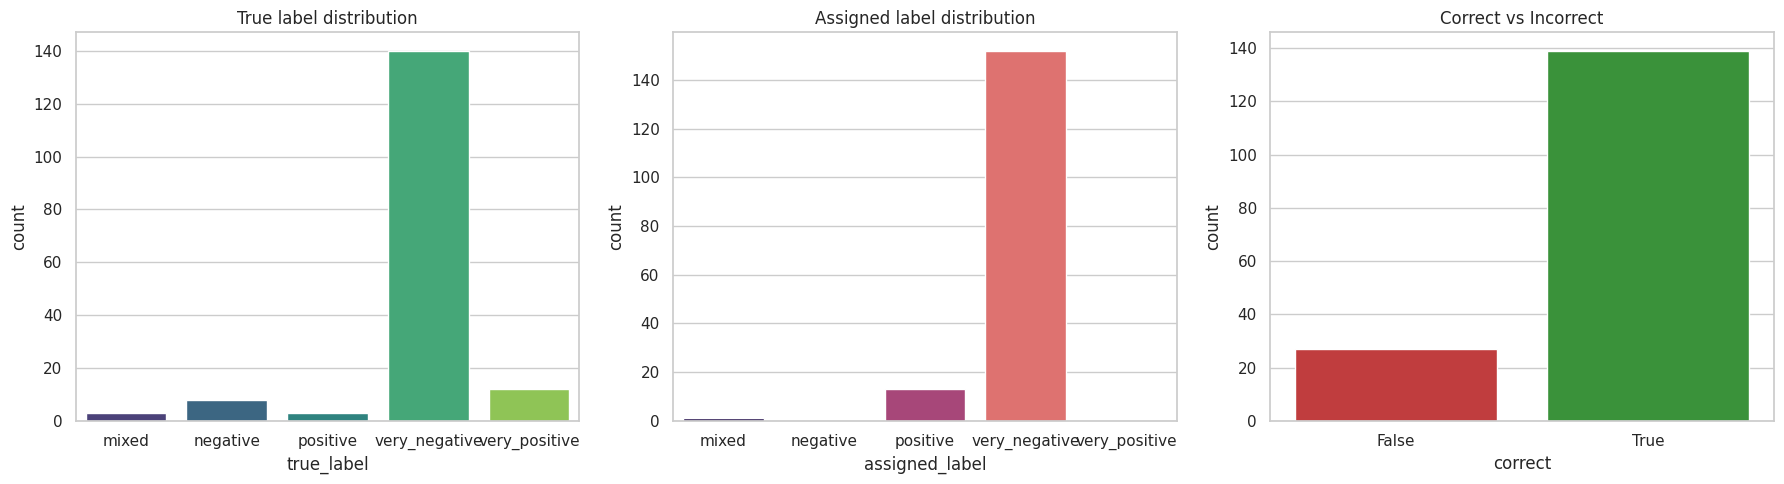

In [15]:
# Section 6: True vs Predicted Comparison Diagram

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True distribution
sns.countplot(x="true_label", data=df, order=labels, ax=axes[0], palette="viridis")
axes[0].set_title("True label distribution")

# Predicted distribution
sns.countplot(x="assigned_label", data=df, order=labels, ax=axes[1], palette="magma")
axes[1].set_title("Assigned label distribution")

# Correct vs incorrect
df["correct"] = df["true_label"] == df["assigned_label"]
sns.countplot(x="correct", data=df, ax=axes[2], palette=["#d62728", "#2ca02c"]) 
axes[2].set_title("Correct vs Incorrect")

plt.tight_layout()
plt.savefig(FIG_DIR / "label_distributions.png")
plt.show()


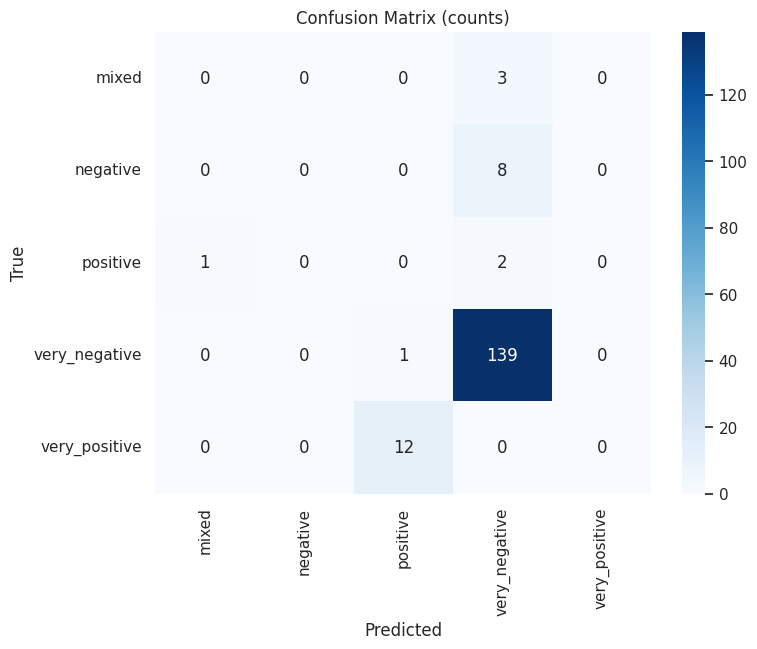

found score-like column: mem_very_negative


In [19]:
# Section 7: Confusion Matrix and Threshold Sweep
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (counts)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig(FIG_DIR / 'confusion_matrix.png')
plt.show()

# threshold sweep if score column exists
score_col = None
for c in df.columns:
    if c.startswith('y_score') or c.startswith('score') or c.startswith('mem_'):
        score_col = c
        break

if score_col and score_col in df.columns:
    print('found score-like column:', score_col)
else:
    print('No per-class score column detected; skipping threshold sweep')


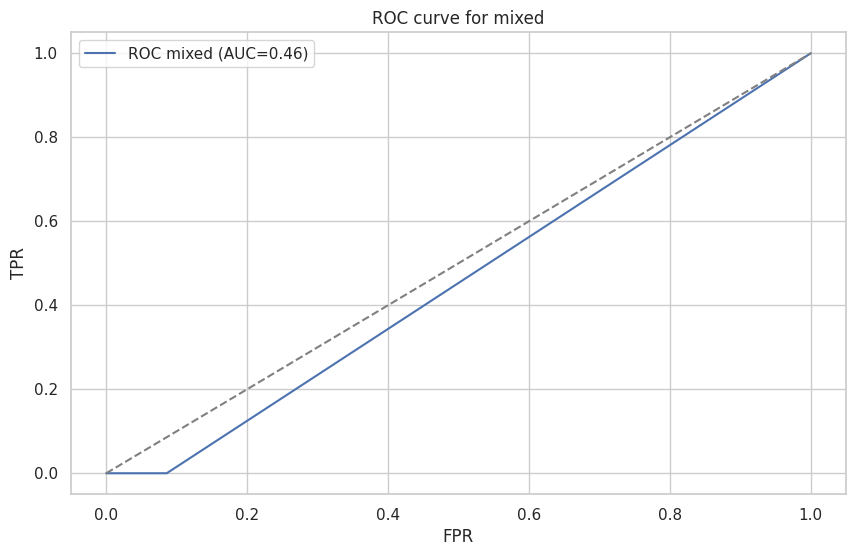

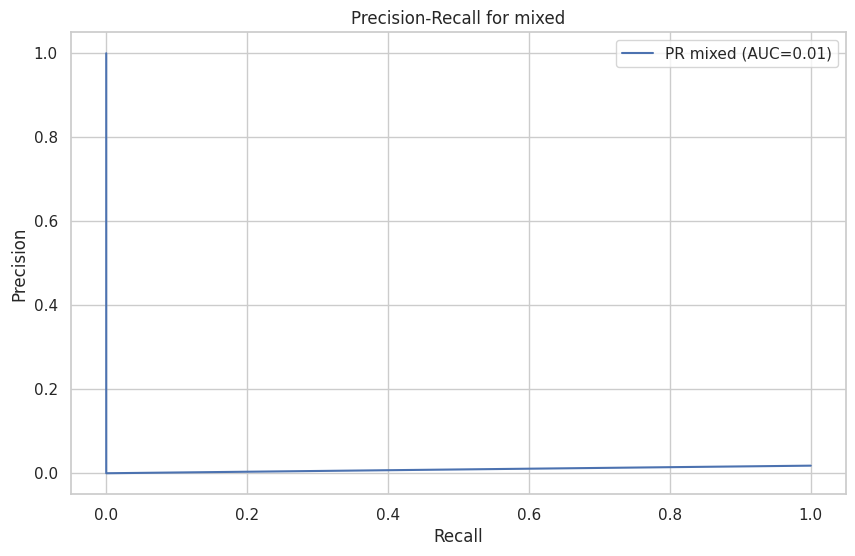

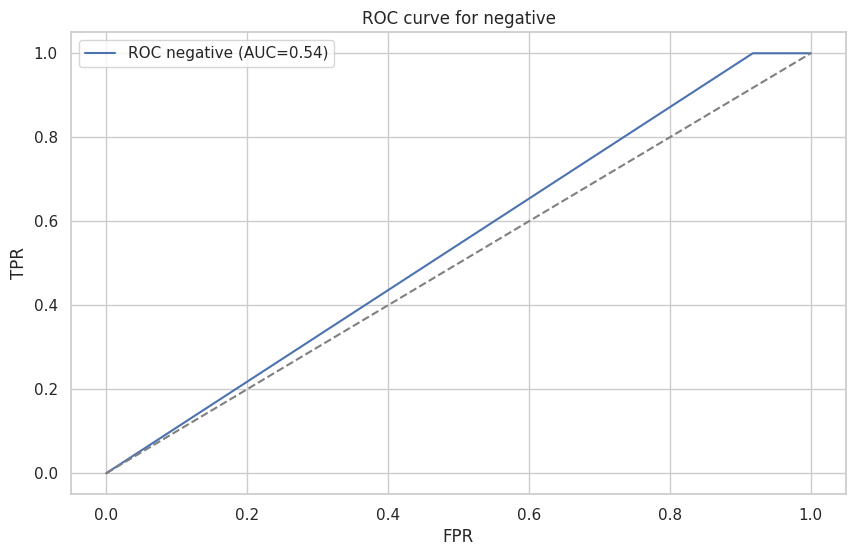

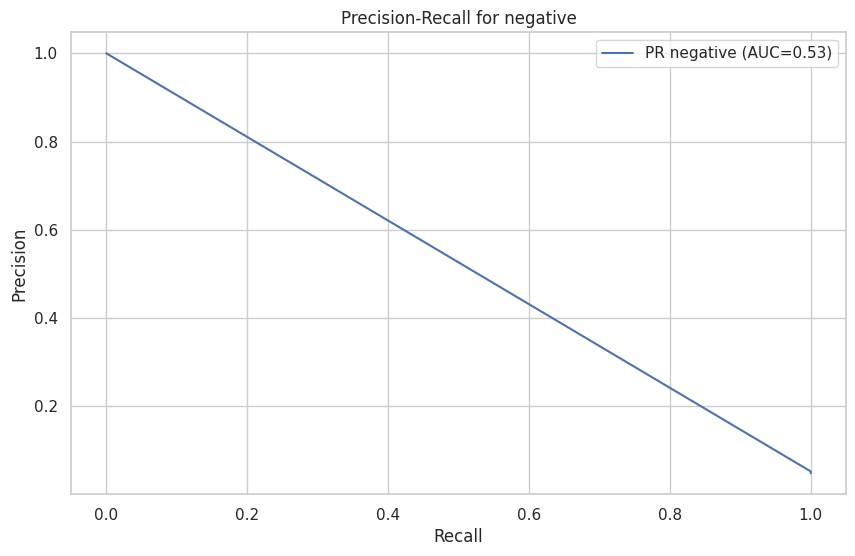

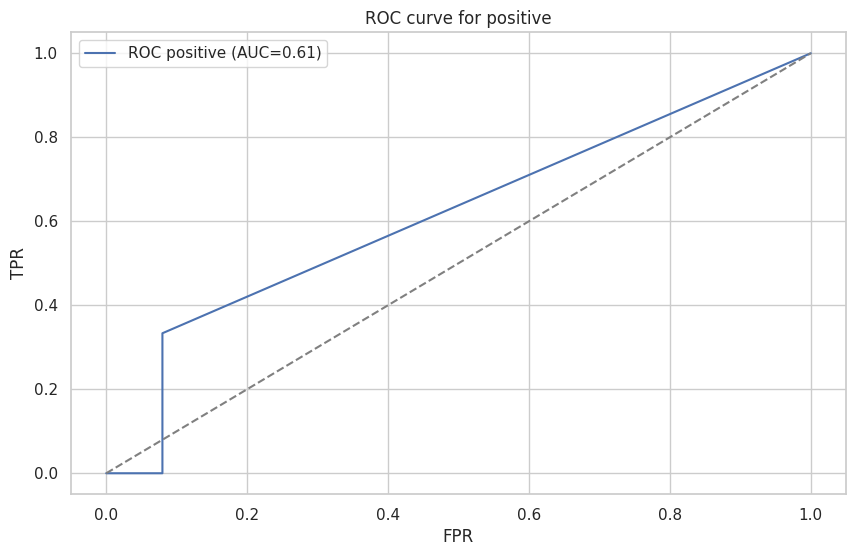

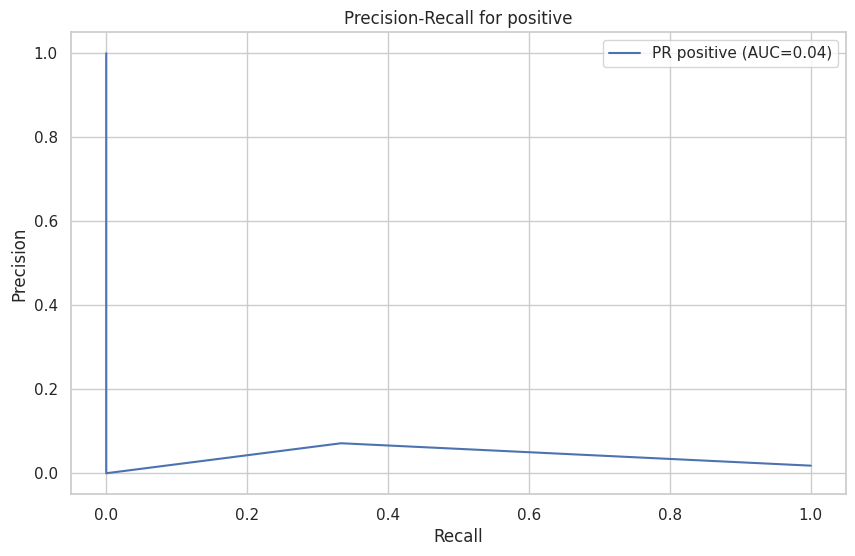

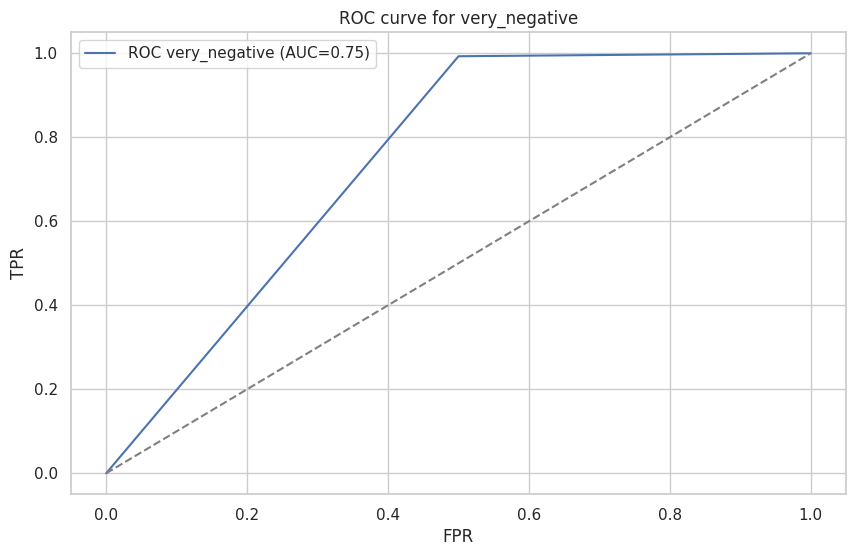

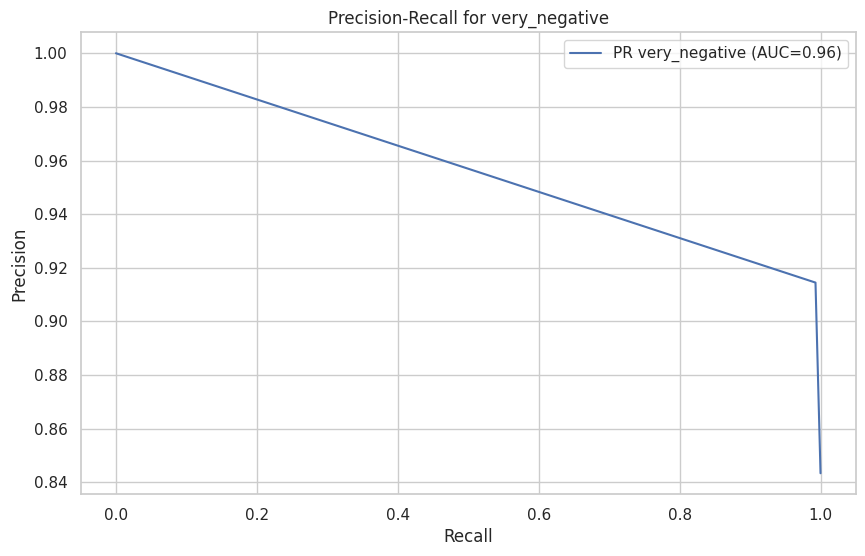

In [17]:
# Section 8: ROC, Precision-Recall, and Lift (if scores available)
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# create mem_true_label column used earlier
if 'mem_true_label' not in df.columns:
    mem_col_for_true = df['true_label'].apply(lambda t: f'mem_{t}')
    mem_values = [float(df.at[i, c]) if c in df.columns else 0.0 for i, c in enumerate(mem_col_for_true)]
    df['mem_true_label'] = mem_values

# If we have probability-like score per row for the true label, use it
if df['mem_true_label'].notnull().any():
    y_score = df['mem_true_label'].values
    # binary ROC/PR for each label vs rest is more appropriate; here show overall using true vs not-true for one label
    # example choose 'very_negative' vs rest
    for lab in labels:
        y_binary = (df['true_label'] == lab).astype(int)
        y_score_lab = df.apply(lambda r: r.get(f'mem_{lab}', 0.0), axis=1)
        if y_score_lab.max() > 0:
            fpr, tpr, _ = roc_curve(y_binary, y_score_lab)
            roc_auc = auc(fpr, tpr)
            plt.figure()
            plt.plot(fpr, tpr, label=f'ROC {lab} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'--', color='gray')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title(f'ROC curve for {lab}')
            plt.legend()
            plt.savefig(FIG_DIR / f'roc_{lab}.png')
            plt.show()

            prec, rec, _ = precision_recall_curve(y_binary, y_score_lab)
            pr_auc = auc(rec, prec)
            plt.figure()
            plt.plot(rec, prec, label=f'PR {lab} (AUC={pr_auc:.2f})')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall for {lab}')
            plt.legend()
            plt.savefig(FIG_DIR / f'pr_{lab}.png')
            plt.show()


In [ ]:
# Section 9: Show Top Misclassified Examples
misclassified = df[df['true_label'] != df['assigned_label']].copy()
if len(misclassified) == 0:
    print('No misclassifications found')
else:
    display_cols = ['ID', 'Review', 'Rating', 'ai_ranking', 'true_label', 'assigned_label', 'mem_true_label']
    display_cols = [c for c in display_cols if c in df.columns]
    display(misclassified[display_cols].head(10))
